# Legacy versus double-HG light maps

This notebook compares the historical isotropic/Rayleigh-style light maps with the new double-lobe Henyey–Greenstein maps at identical nominal scattering lengths. Curves are overlaid; spatial response volumes are shown as ten matched 2D slices, with the legacy and double-HG maps side by side and on the same colour scale.

The comparison isolates the scattering implementation. All selected maps use 1 mm fibres, 5 m absorption length, 100k photons per source point, and the new maps use `g=0.5`, `r_fb=0.75`, and scintillator refractive index 1.48.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from compare_lightmap_efficiencies import compare_lightmaps

maps = Path('lightmaps')
output_dir = Path('lightmap_analysis/old_vs_double_hg')
output_dir.mkdir(parents=True, exist_ok=True)

## Input maps

Edit these lists when further matched light maps are added. The first value is the nominal scattering mean free path in millimetres; matching is performed using that value, not list order.

In [2]:
old_settings = [
    (0.25, '0.25 mm old', maps / 'homo_response_10bin_5m_0p25mm_100kPhotons.root'),
    (0.40, '0.40 mm old', maps / 'homo_response_10bin_5m_0p4mm_100kPhotons.root'),
    (0.55, '0.55 mm old', maps / 'homo_response_10bin_5m_0p55mm_fibre-1p0mm_100kPhotons.root'),
    (0.70, '0.70 mm old', maps / 'homo_response_10bin_5m_0p7mm_100kPhotons.root'),
    (0.85, '0.85 mm old', maps / 'homo_response_10bin_5m_0p85mm_fibre-1p0mm_100kPhotons.root'),
    (1.00, '1.00 mm old', maps / 'homo_response_10bin_5m_1p0mm_100kPhotons.root'),
    (1.50, '1.50 mm old', maps / 'homo_response_10bin_5m_1p5mm_fibre-1p0mm_100kPhotons.root'),
]
new_settings = [
    (s, f'{s:g} mm double-HG', maps / f'homo_response_10bin_5m_double_hg_{str(s).replace(".", "p")}mm_g-0p5_rfb-0p75_fibre-1p0mm_scin-ri-1p48_100kPhotons.root')
    for s in (0.25, 0.4, 0.55, 0.7, 0.85, 1.0, 1.5)
]

missing = [path for _, _, path in old_settings + new_settings if not path.exists()]
if missing:
    raise FileNotFoundError('Missing input maps:\n' + '\n'.join(map(str, missing)))

old_summaries, old_detailed = compare_lightmaps(old_settings, output_dir / 'old')
new_summaries, new_detailed = compare_lightmaps(new_settings, output_dir / 'double_hg')
old_summary = pd.DataFrame(old_summaries).set_index('scatter_length_mm').sort_index()
new_summary = pd.DataFrame(new_summaries).set_index('scatter_length_mm').sort_index()
common = old_summary.index.intersection(new_summary.index)
print('Matched scattering lengths [mm]:', list(common))
display(pd.concat({'old': old_summary.loc[common], 'double-HG': new_summary.loc[common]}, names=['model']))

Matched scattering lengths [mm]: [0.25, 0.4, 0.55, 0.7, 0.85, 1.0, 1.5]


label  \
model     scatter_length_mm                      
old       0.25                     0.25 mm old   
          0.40                     0.40 mm old   
          0.55                     0.55 mm old   
          0.70                     0.70 mm old   
          0.85                     0.85 mm old   
          1.00                     1.00 mm old   
          1.50                     1.50 mm old   
double-HG 0.25               0.25 mm double-HG   
          0.40                0.4 mm double-HG   
          0.55               0.55 mm double-HG   
          0.70                0.7 mm double-HG   
          0.85               0.85 mm double-HG   
          1.00                  1 mm double-HG   
          1.50                1.5 mm double-HG   

                                                                         input  \
model     scatter_length_mm                                                      
old       0.25               lightmaps/homo_response_10bin_5m_0p25mm_100kPh...   
          0.40               lightmaps/homo_response_10bin_5m_0p4mm_100kPho...   
          0.55               lightmaps/homo_response_10bin_5m_0p55mm_fibre-...   
          0.70               lightmaps/homo_response_10bin_5m_0p7mm_100kPho...   
          0.85               lightmaps/homo_response_10bin_5m_0p85mm_fibre-...   
          1.00               lightmaps/homo_response_10bin_5m_1p0mm_100kPho...   
          1.50               lightmaps/homo_response_10bin_5m_1p5mm_fibre-1...   
double-HG 0.25               lightmaps/homo_response_10bin_5m_double_hg_0p2...   
          0.40               lightmaps/homo_response_10bin_5m_double_hg_0p4...   
          0.55               lightmaps/homo_response_10bin_5m_double_hg_0p5...   
          0.70               lightmaps/homo_response_10bin_5m_double_hg_0p7...   
          0.85               lightmaps/homo_response_10bin_5m_double_hg_0p8...   
          1.00               lightmaps/homo_response_10bin_5m_double_hg_1p0...   
          1.50               lightmaps/homo_response_10bin_5m_double_hg_1p5...   

                             positions  total_mean  total_min  total_max  \
model     scatter_length_mm                                                
old       0.25                     970    0.813149    0.80642    0.81744   
          0.40                     970    0.870520    0.86529    0.87503   
          0.55                     970    0.900306    0.89438    0.90438   
          0.70                     970    0.918565    0.91411    0.92217   
          0.85                     970    0.930878    0.92513    0.93395   
          1.00                     970    0.939875    0.93603    0.94280   
          1.50                     970    0.957288    0.95398    0.95963   
double-HG 0.25                     970    0.983141    0.97781    0.98971   
          0.40                     970    0.987031    0.98346    0.99140   
          0.55                     970    0.988686    0.98632    0.99206   
          0.70                     970    0.989572    0.98743    0.99238   
          0.85                     970    0.990128    0.98791    0.99281   
          1.00                     970    0.990512    0.98868    0.99294   
          1.50                     970    0.991196    0.98980    0.99311   

                             total_rms  view_x_mean  view_x_min  view_x_max  \
model     scatter_length_mm                                                   
old       0.25                0.001919     0.271042     0.10460     0.55562   
          0.40                0.001756     0.290160     0.12984     0.56257   
          0.55                0.001636     0.300174     0.14933     0.55576   
          0.70                0.001475     0.306159     0.16300     0.54532   
          0.85                0.001414     0.310345     0.17614     0.53544   
          1.00                0.001282     0.313318     0.18797     0.52590   
          1.50                0.001071     0.319156     0.21163     0.50151   

Warning in <TClass::Init>: no dictionary for class ND::TND280Event is available
Warning in <TClass::Init>: no dictionary for class ND::TDataVector is available
Warning in <TClass::Init>: no dictionary for class ND::TData is available
Warning in <TClass::Init>: no dictionary for class ND::TDatum is available
Warning in <TClass::Init>: no dictionary for class ND::TND280Context is available
Warning in <TClass::Init>: no dictionary for class ND::TSHAHashValue is available
Warning in <TClass::Init>: no dictionary for class ND::TAlignmentId is available
Warning in <TClass::Init>: no dictionary for class ND::TND280Event::Header is available


## Overlaid scalar and per-view comparisons

Solid circles denote the old model; dashed squares denote double-HG. X/Y/Z view colours remain fixed across all figures.

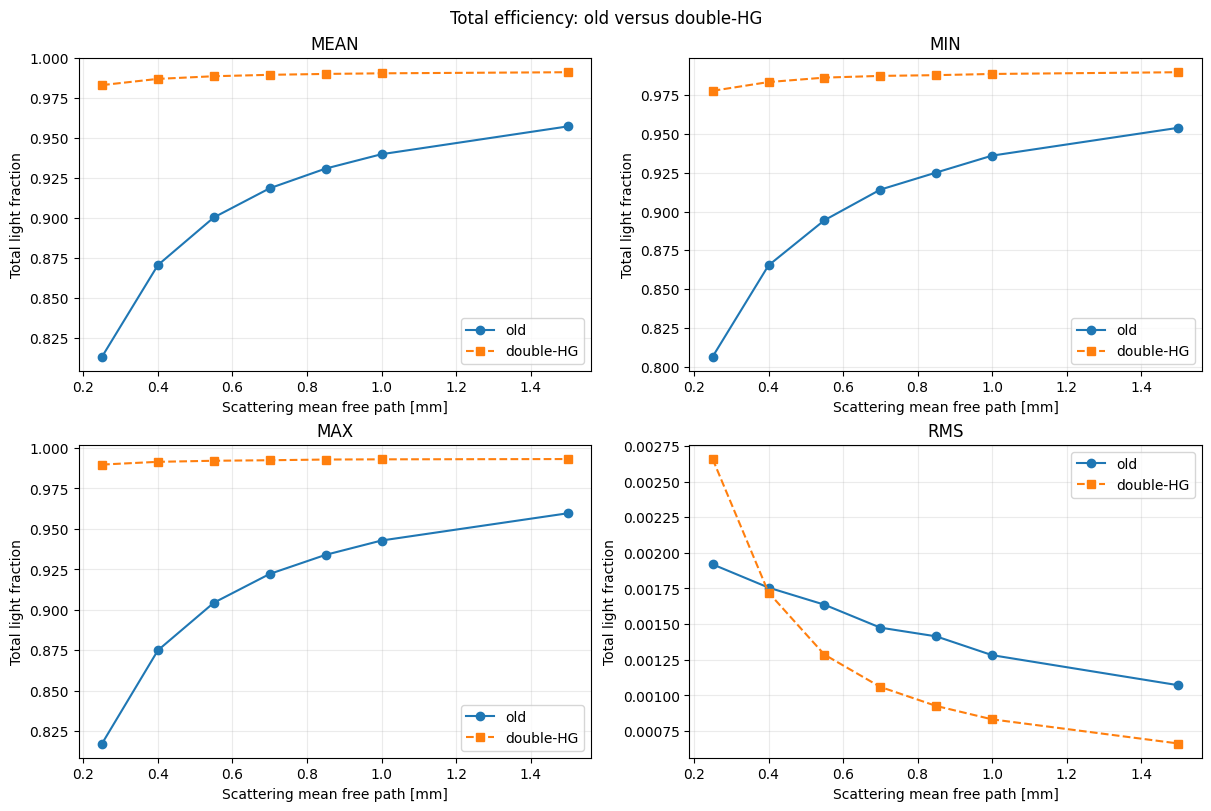

In [3]:
styles = {'old': ('-', 'o'), 'double-HG': ('--', 's')}
view_colours = {'x': '#e45756', 'y': '#4c78a8', 'z': '#54a24b'}
frames = {'old': old_summary.loc[common], 'double-HG': new_summary.loc[common]}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for ax, statistic in zip(axes.flat, ('mean', 'min', 'max', 'rms')):
    for model, frame in frames.items():
        ls, marker = styles[model]
        ax.plot(common, frame[f'total_{statistic}'], linestyle=ls, marker=marker, label=model)
    ax.set(title=statistic.upper(), xlabel='Scattering mean free path [mm]', ylabel='Total light fraction')
    ax.grid(alpha=.25); ax.legend()
fig.suptitle('Total efficiency: old versus double-HG')
fig.savefig(output_dir / 'total_efficiency_old_vs_double_hg.png', dpi=170)
plt.show()

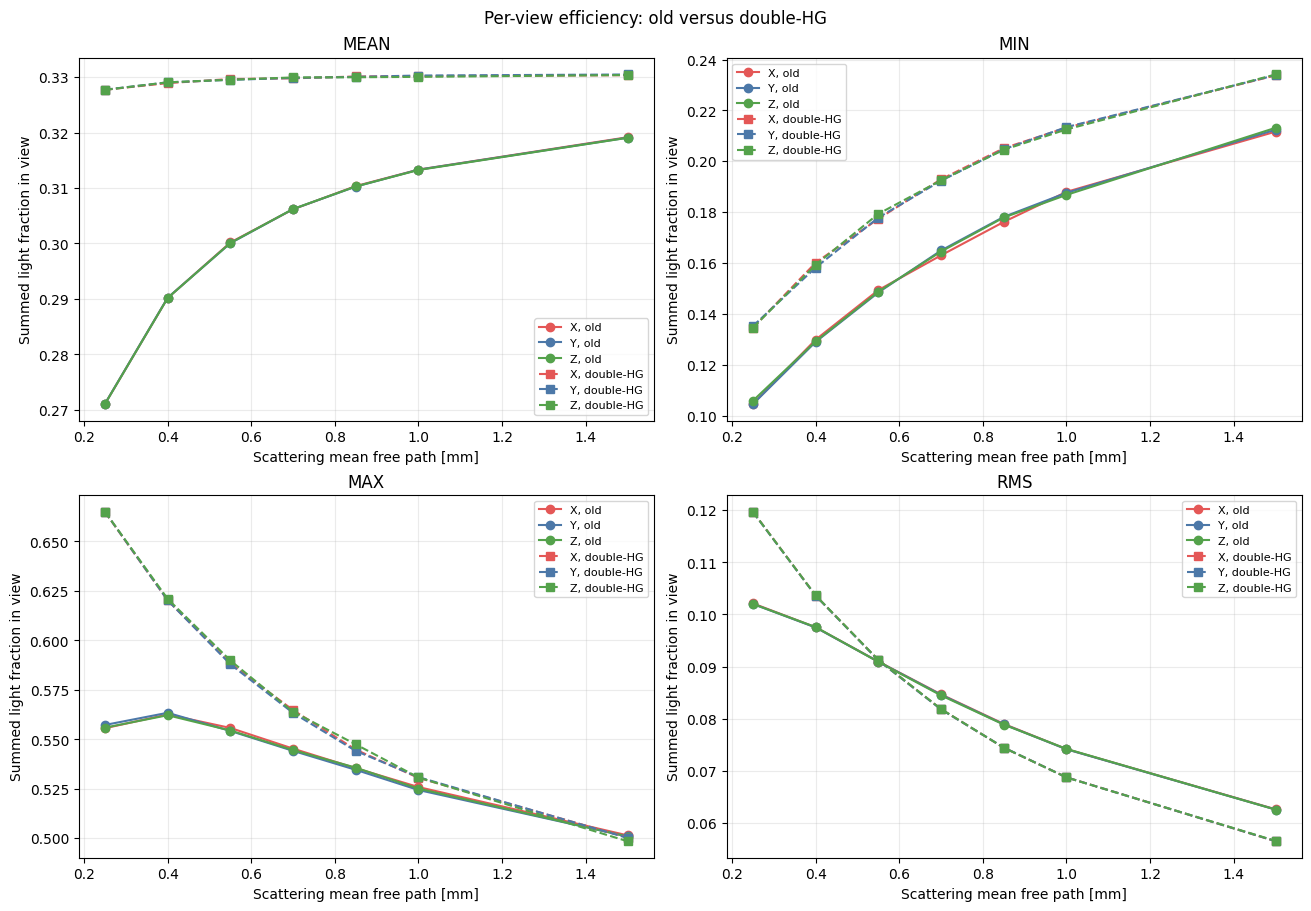

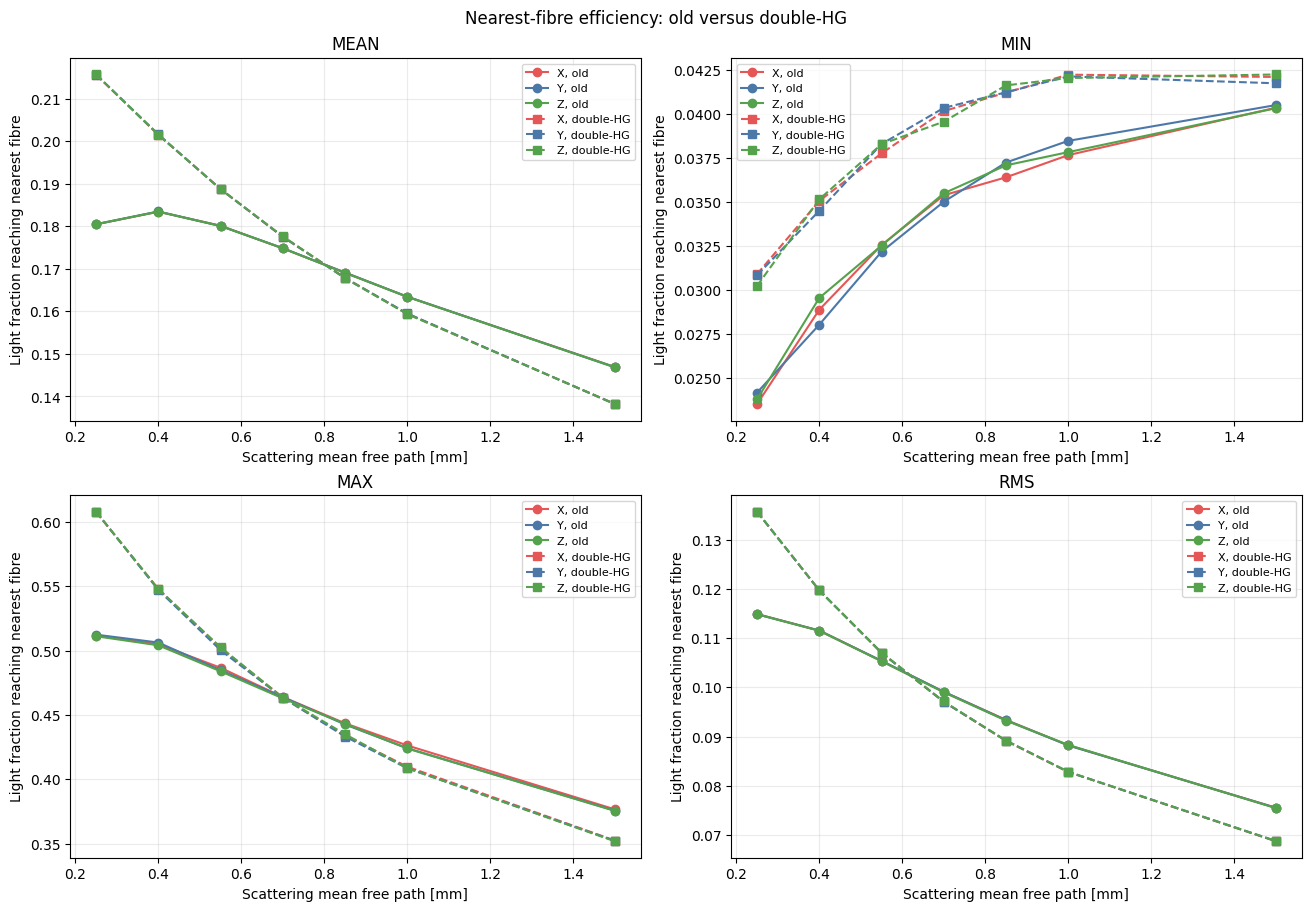

In [4]:
def plot_view_overlay(prefix, ylabel, title, filename):
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
    for ax, statistic in zip(axes.flat, ('mean', 'min', 'max', 'rms')):
        for model, frame in frames.items():
            ls, marker = styles[model]
            for view in ('x', 'y', 'z'):
                ax.plot(common, frame[f'{prefix}_{view}_{statistic}'], linestyle=ls, marker=marker,
                        color=view_colours[view], label=f'{view.upper()}, {model}')
        ax.set(title=statistic.upper(), xlabel='Scattering mean free path [mm]', ylabel=ylabel)
        ax.grid(alpha=.25); ax.legend(fontsize=8)
    fig.suptitle(title)
    fig.savefig(output_dir / filename, dpi=170)
    plt.show()

plot_view_overlay('view', 'Summed light fraction in view',
                  'Per-view efficiency: old versus double-HG',
                  'view_efficiency_old_vs_double_hg.png')
plot_view_overlay('nearest', 'Light fraction reaching nearest fibre',
                  'Nearest-fibre efficiency: old versus double-HG',
                  'nearest_fibre_old_vs_double_hg.png')

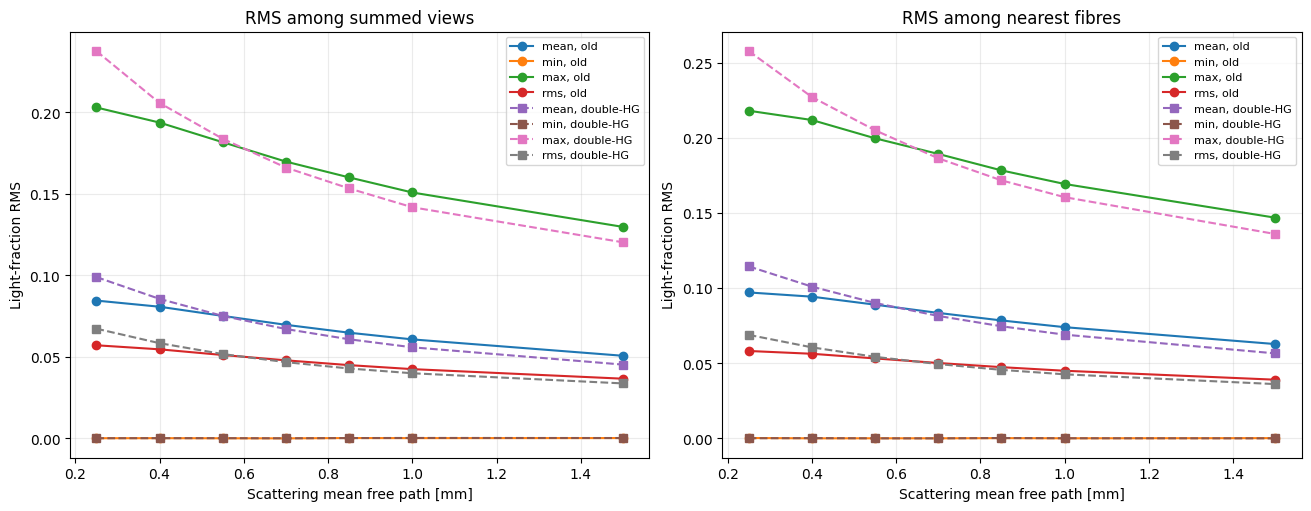

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, prefix, title in ((axes[0], 'view_rms', 'RMS among summed views'),
                          (axes[1], 'nearest_view_rms', 'RMS among nearest fibres')):
    for model, frame in frames.items():
        ls, marker = styles[model]
        for statistic in ('mean', 'min', 'max', 'rms'):
            ax.plot(common, frame[f'{prefix}_{statistic}'], linestyle=ls, marker=marker,
                    label=f'{statistic}, {model}')
    ax.set(title=title, xlabel='Scattering mean free path [mm]', ylabel='Light-fraction RMS')
    ax.grid(alpha=.25); ax.legend(fontsize=8)
fig.savefig(output_dir / 'view_imbalance_old_vs_double_hg.png', dpi=170)
plt.show()

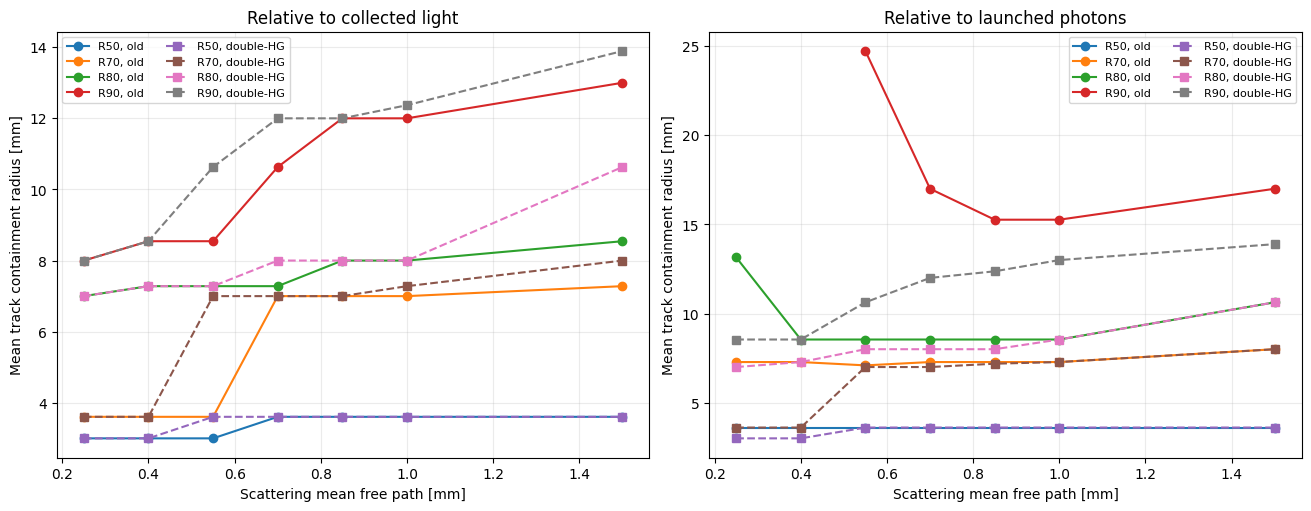

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, normalization, title in ((axes[0], 'relative', 'Relative to collected light'),
                                  (axes[1], 'absolute', 'Relative to launched photons')):
    for model, frame in frames.items():
        ls, marker = styles[model]
        for fraction in (50, 70, 80, 90):
            ax.plot(common, frame[f'{normalization}_r{fraction}_mean_mm'], linestyle=ls,
                    marker=marker, label=f'R{fraction}, {model}')
    ax.set(title=title, xlabel='Scattering mean free path [mm]', ylabel='Mean track containment radius [mm]')
    ax.grid(alpha=.25); ax.legend(fontsize=8, ncol=2)
fig.savefig(output_dir / 'track_containment_old_vs_double_hg.png', dpi=170)
plt.show()

## Side-by-side spatial maps

Choose a matched `SCATTER_LENGTH` and a quantity. Available quantities include `total`, `view_x`, `view_y`, `view_z`, `view_rms`, `nearest_x`, `nearest_y`, `nearest_z`, and `nearest_view_rms`. Each row is one source-position Z slice. Both columns use exactly the same colour normalization.

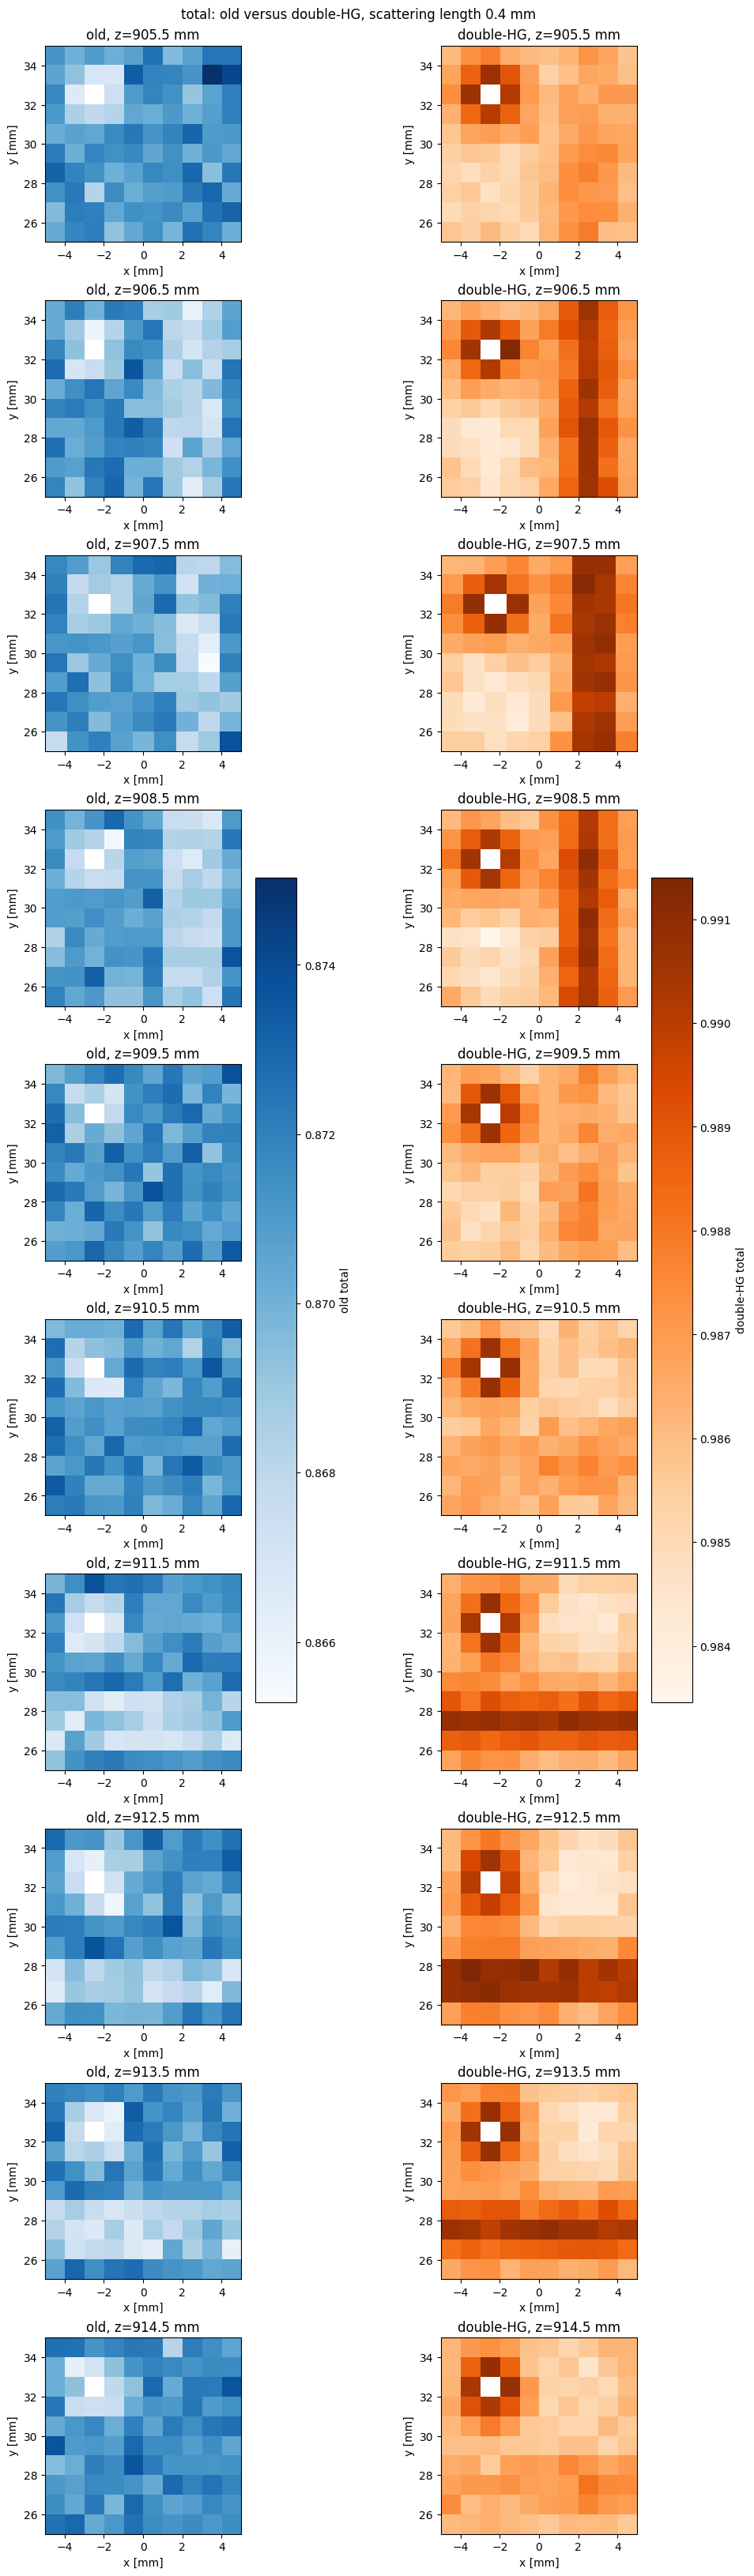

In [7]:
SCATTER_LENGTH = 0.40
MAP_QUANTITY = 'total'

old_labels = {s: label for s, label, _ in old_settings}
new_labels = {s: label for s, label, _ in new_settings}

def records_frame(records):
    frame = pd.DataFrame(records).copy()
    for coordinate in ('x_mm', 'y_mm', 'z_mm'):
        frame[coordinate] = frame[coordinate].round(6)
    return frame

def plot_slice_pair(scatter_length, quantity='total', save=True):
    if scatter_length not in old_labels or scatter_length not in new_labels:
        raise ValueError(f'No matched pair for {scatter_length} mm')
    old = records_frame(old_detailed[old_labels[scatter_length]])
    new = records_frame(new_detailed[new_labels[scatter_length]])
    z_values = sorted(set(old.z_mm) & set(new.z_mm))
    if len(z_values) != 10:
        print(f'Warning: expected 10 common Z slices, found {len(z_values)}')
    # The two models can have substantially different absolute scales.
    # Give each model its own normalization and palette so neither map is
    # visually compressed by the range of the other.
    norms = {
        'old': Normalize(vmin=np.nanmin(old[quantity]), vmax=np.nanmax(old[quantity])),
        'double-HG': Normalize(vmin=np.nanmin(new[quantity]), vmax=np.nanmax(new[quantity])),
    }
    cmaps = {'old': 'Blues', 'double-HG': 'Oranges'}
    fig, axes = plt.subplots(len(z_values), 2, figsize=(10, 3.25*len(z_values)),
                             constrained_layout=True, squeeze=False)
    images = {}
    for row, z_value in enumerate(z_values):
        for column, (model, frame) in enumerate((('old', old), ('double-HG', new))):
            selected = frame[np.isclose(frame.z_mm, z_value)]
            grid = selected.pivot(index='y_mm', columns='x_mm', values=quantity).sort_index().sort_index(axis=1)
            images[model] = axes[row, column].imshow(grid.to_numpy(), origin='lower', aspect='equal',
                                             norm=norms[model], cmap=cmaps[model],
                                             extent=(grid.columns.min()-.5, grid.columns.max()+.5,
                                                     grid.index.min()-.5, grid.index.max()+.5))
            axes[row, column].set(title=f'{model}, z={z_value:g} mm', xlabel='x [mm]', ylabel='y [mm]')
    fig.colorbar(images['old'], ax=axes[:, 0], label=f'old {quantity}', shrink=.6)
    fig.colorbar(images['double-HG'], ax=axes[:, 1], label=f'double-HG {quantity}', shrink=.6)
    fig.suptitle(f'{quantity}: old versus double-HG, scattering length {scatter_length:g} mm')
    if save:
        safe_quantity = quantity.replace('/', '_')
        fig.savefig(output_dir / f'slices_{safe_quantity}_{scatter_length:g}mm_old_vmv /home/tlux/HK/ND280++/ND280Reco_doubleHG_fixed_new.sif /home/tlux/HK/ND280++/ND280Reco_doubleHG_fixed.sifs_double_hg.png', dpi=150)
    plt.show()

plot_slice_pair(SCATTER_LENGTH, MAP_QUANTITY)

### Optional difference slices

The following uses `double-HG − old` with a symmetric colour scale. It requires identical source coordinates in the two maps and reports any mismatch rather than silently pairing rows by order.

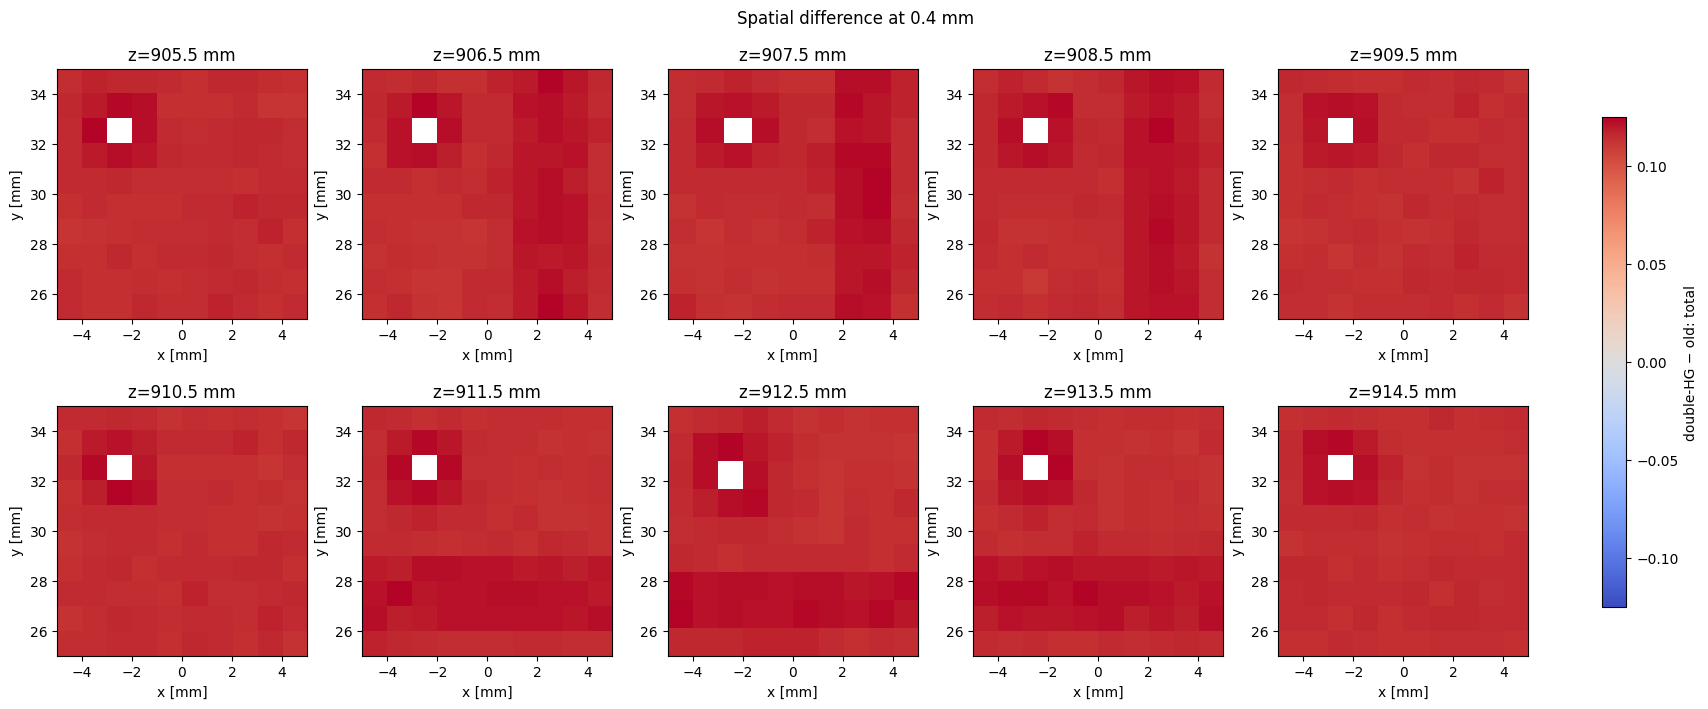

In [8]:
def plot_difference_slices(scatter_length, quantity='total'):
    old = records_frame(old_detailed[old_labels[scatter_length]])
    new = records_frame(new_detailed[new_labels[scatter_length]])
    keys = ['x_mm', 'y_mm', 'z_mm']
    merged = old[keys + [quantity]].merge(new[keys + [quantity]], on=keys, suffixes=('_old', '_new'), validate='one_to_one')
    if len(merged) != len(old) or len(merged) != len(new):
        raise ValueError(f'Coordinate mismatch: old={len(old)}, new={len(new)}, matched={len(merged)}')
    merged['difference'] = merged[f'{quantity}_new'] - merged[f'{quantity}_old']
    z_values = sorted(merged.z_mm.unique())
    limit = np.nanmax(np.abs(merged.difference))
    fig, axes = plt.subplots(2, 5, figsize=(17, 7), constrained_layout=True)
    image = None
    for ax, z_value in zip(axes.flat, z_values):
        selected = merged[np.isclose(merged.z_mm, z_value)]
        grid = selected.pivot(index='y_mm', columns='x_mm', values='difference').sort_index().sort_index(axis=1)
        image = ax.imshow(grid.to_numpy(), origin='lower', cmap='coolwarm', vmin=-limit, vmax=limit,
                          extent=(grid.columns.min()-.5, grid.columns.max()+.5,
                                  grid.index.min()-.5, grid.index.max()+.5))
        ax.set(title=f'z={z_value:g} mm', xlabel='x [mm]', ylabel='y [mm]')
    fig.colorbar(image, ax=axes, label=f'double-HG − old: {quantity}', shrink=.75)
    fig.suptitle(f'Spatial difference at {scatter_length:g} mm')
    plt.show()

# Uncomment when wanted:
plot_difference_slices(SCATTER_LENGTH, MAP_QUANTITY)

## Efficiency versus distance to the nearest fibre axis

For every source subvoxel, the distance is the shortest perpendicular distance to any fibre axis. Individual subvoxels are shown faintly; points with error bars are the mean and population RMS at each discrete distance. Old and double-HG results use the same blue/orange convention as the slice maps.

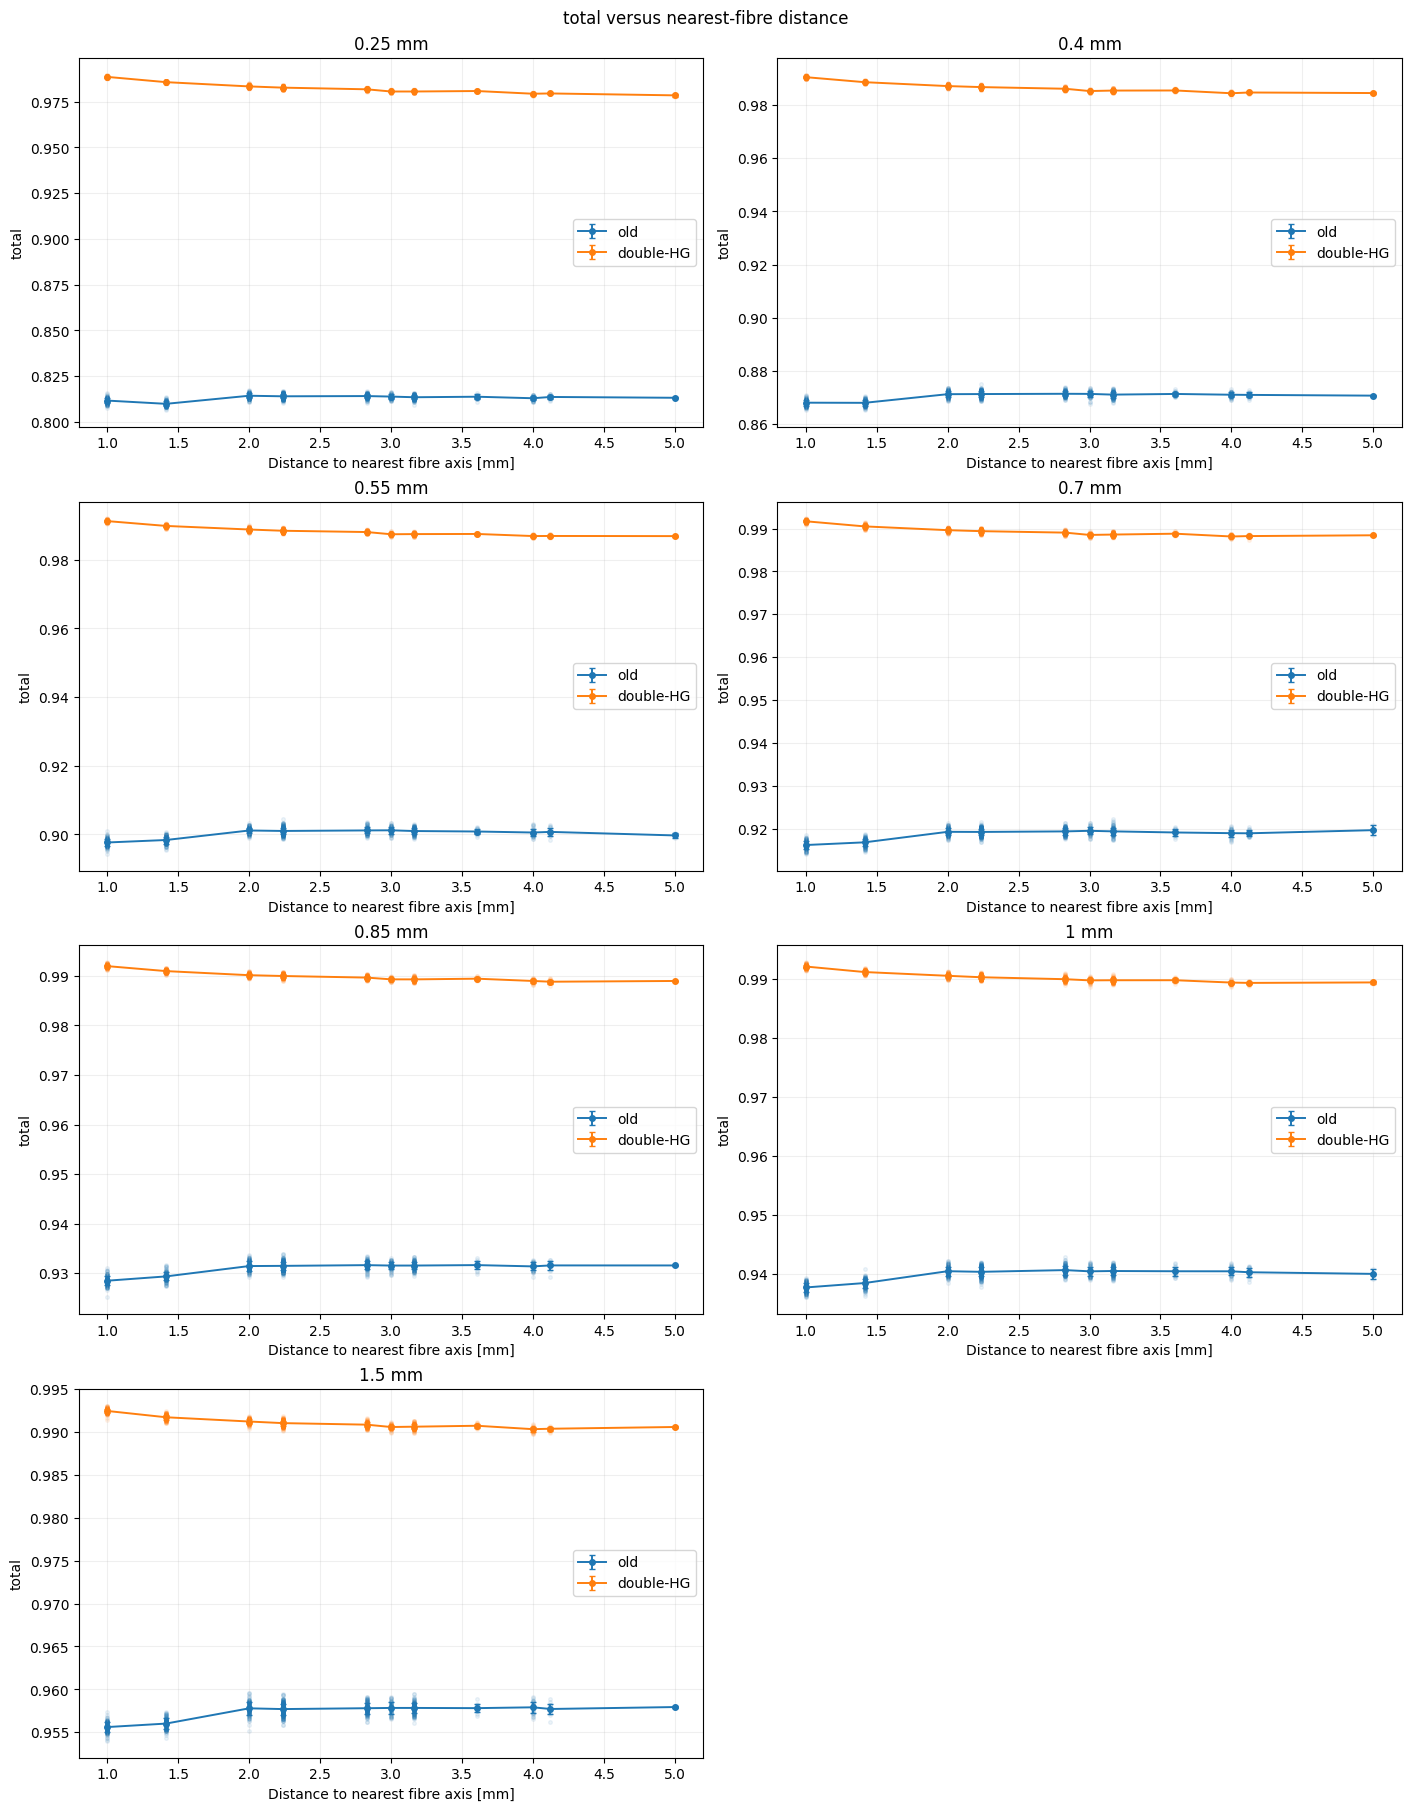

In [9]:
def distance_profile(frame, quantity='total'):
    frame = records_frame(frame)
    distance_columns = [f'nearest_distance_{view}_mm' for view in 'xyz']
    profile = pd.DataFrame({'distance_mm': frame[distance_columns].min(axis=1).round(6), 'efficiency': frame[quantity]})
    summary = profile.groupby('distance_mm').efficiency.agg(['mean', lambda values: values.std(ddof=0)]).reset_index()
    summary.columns = ['distance_mm', 'mean', 'rms']
    return profile, summary

def plot_efficiency_vs_fibre_distance(scatter_lengths=None, quantity='total'):
    scatter_lengths = list(common if scatter_lengths is None else scatter_lengths)
    ncols, nrows = 2, int(np.ceil(len(scatter_lengths) / 2))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5*nrows), constrained_layout=True, squeeze=False)
    for ax, scatter_length in zip(axes.flat, scatter_lengths):
        for model, details, labels, color in (('old', old_detailed, old_labels, 'tab:blue'), ('double-HG', new_detailed, new_labels, 'tab:orange')):
            profile, summary = distance_profile(details[labels[scatter_length]], quantity)
            ax.scatter(profile.distance_mm, profile.efficiency, s=7, alpha=.08, color=color)
            ax.errorbar(summary.distance_mm, summary['mean'], yerr=summary.rms, marker='o', ms=4, capsize=2, lw=1.4, color=color, label=model)
        ax.set(title=f'{scatter_length:g} mm', xlabel='Distance to nearest fibre axis [mm]', ylabel=quantity)
        ax.grid(alpha=.2)
        ax.legend()
    for ax in axes.flat[len(scatter_lengths):]: ax.set_visible(False)
    fig.suptitle(f'{quantity} versus nearest-fibre distance')
    fig.savefig(output_dir / f'{quantity}_vs_nearest_fibre_distance_old_vs_double_hg.png', dpi=170)
    plt.show()

plot_efficiency_vs_fibre_distance(quantity=MAP_QUANTITY)